# US Treasury Note — Full Pricing Roundtrip

Build a discount curve from realistic SOFR rates, price a 10Y Treasury note, and explore every dimension: yield, accrued interest, clean/dirty price, duration, DV01, carry, 32nds quoting.

In [1]:
import sys, os, math
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "python"))

import numpy as np

from datetime import date
from dateutil.relativedelta import relativedelta

from pricebook.bond import FixedRateBond
from pricebook.bootstrap import bootstrap
from pricebook.discount_curve import DiscountCurve
from pricebook.day_count import DayCountConvention, year_fraction
from pricebook.treasury_quoting import to_32nds, from_32nds, tick_value
from pricebook.bond_trading_desk import bond_risk_metrics, bond_carry_roll
from pricebook.viz import configure_theme, greeks_profile, sensitivity_grid

# Apply seaborn styling
configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")

# ── 1. Market Data (as-of 15 Jul 2024) ──
REF = date(2024, 7, 15)
deposits = [
    (REF + relativedelta(months=1), 0.0530),
    (REF + relativedelta(months=3), 0.0528),
    (REF + relativedelta(months=6), 0.0515),
]
swaps = [
    (REF + relativedelta(years=1), 0.0490),
    (REF + relativedelta(years=2), 0.0455),
    (REF + relativedelta(years=3), 0.0435),
    (REF + relativedelta(years=5), 0.0410),
    (REF + relativedelta(years=7), 0.0400),
    (REF + relativedelta(years=10), 0.0390),
    (REF + relativedelta(years=20), 0.0405),
    (REF + relativedelta(years=30), 0.0415),
]
curve = bootstrap(REF, deposits, swaps)

print("Discount Curve (SOFR-based):")
for tenor, label in [(1, "1Y"), (2, "2Y"), (5, "5Y"), (10, "10Y"), (30, "30Y")]:
    d = REF + relativedelta(years=tenor)
    print(f"  {label}: df={curve.df(d):.6f}, zero={curve.zero_rate(d)*100:.2f}%")

Discount Curve (SOFR-based):
  1Y: df=0.952785, zero=4.84%
  2Y: df=0.914133, zero=4.49%
  5Y: df=0.817333, zero=4.03%
  10Y: df=0.681881, zero=3.83%
  30Y: df=0.285395, zero=4.18%


## 2. Create the 10Y Treasury Note

4.25% coupon, issued Feb 2024, matures Feb 2034. Semi-annual coupons, ACT/ACT, T+1 settlement.

In [2]:
# Create 10Y T-Note via factory method
tnote = FixedRateBond.treasury_note(
    issue_date=date(2024, 2, 15),
    maturity=date(2034, 2, 15),
    coupon_rate=0.0425,
)

settle = tnote.settlement_date(REF)

print(f"Bond:       {tnote.coupon_rate*100:.2f}% T-Note due {tnote.maturity}")
print(f"Issue:      {tnote.issue_date}")
print(f"Trade date: {REF}")
print(f"Settlement: {settle} (T+{tnote.settlement_days})")
print(f"Face value: {tnote.face_value}")
print(f"Day count:  ACT/ACT ICMA")
print(f"Frequency:  Semi-annual")

# ── Pricing ──
dirty = tnote.dirty_price(curve)
ai = tnote.accrued_interest(settle)
clean = tnote.clean_price(curve, settle)
ytm = tnote.yield_to_maturity(dirty, settle)

print(f"\n{'─'*50}")
print(f"Dirty price:     {dirty:>10.6f}")
print(f"Accrued interest:{ai:>10.6f}")
print(f"Clean price:     {clean:>10.6f}")
print(f"Yield to maturity: {ytm*100:.4f}%")
print(f"\n32nds quote:     {to_32nds(clean)}")
print(f"  (verify:       {from_32nds(to_32nds(clean)):.6f})")

# ── Roundtrip: price → yield → price ──
price_from_ytm = tnote._price_from_ytm(ytm, settle)
roundtrip_err = abs(price_from_ytm - dirty)
print(f"\nRoundtrip: YTM → price → YTM")
print(f"  dirty_price(curve) = {dirty:.6f}")
print(f"  price_from_ytm({ytm*100:.4f}%) = {price_from_ytm:.6f}")
print(f"  Error: {roundtrip_err:.2e}")

Bond:       4.25% T-Note due 2034-02-15
Issue:      2024-02-15
Trade date: 2024-07-15
Settlement: 2024-07-16 (T+1)
Face value: 100.0
Day count:  ACT/ACT ICMA
Frequency:  Semi-annual

──────────────────────────────────────────────────
Dirty price:     104.453411
Accrued interest:  1.769863
Clean price:     102.683547
Yield to maturity: 3.9114%

32nds quote:     102-22
  (verify:       102.687500)

Roundtrip: YTM → price → YTM
  dirty_price(curve) = 104.453411
  price_from_ytm(3.9114%) = 104.453411
  Error: 4.55e-13


## 3. Risk Metrics (Duration, DV01, Convexity, Key-Rate)

Metric                           Value
───────────────────────── ────────────
Dirty Price (per 100)         104.4534
Clean Price (per 100)         102.6835
Accrued Interest                1.7699
YTM                            3.9114%
Macaulay Duration               7.8674
Modified Duration               7.7165
Effective Duration              7.8846
Convexity                        71.59
DV01 (yield, per 100)           0.0806
DV01 (curve, per 100)          -0.0824

Key-Rate DV01 Profile:
     1M:  -0.0000  
     3M:   0.0000  
     6M:  -0.0001  
     1Y:  -0.0003  
     2Y:  -0.0008  
     3Y:  -0.0017  
     5Y:  -0.0035  █
     7Y:  -0.0122  ██████
    10Y:  -0.0638  ███████████████████████████████
    20Y:   0.0000  
    30Y:   0.0000  


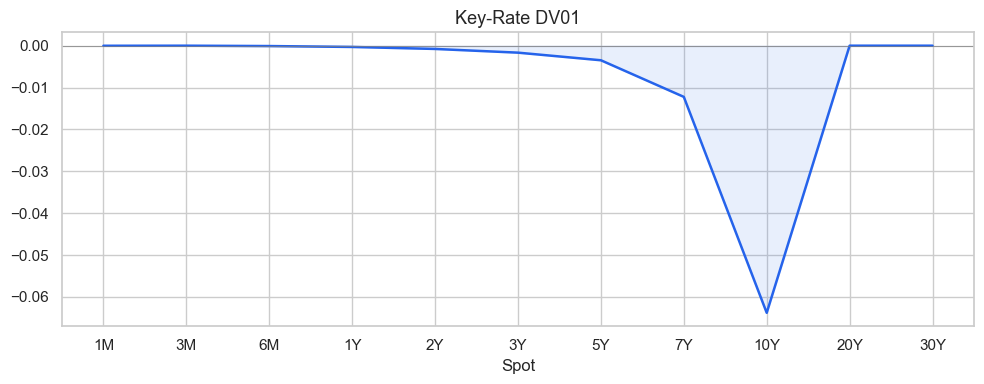

In [3]:
rm = bond_risk_metrics(tnote, curve, settle)

print(f"{'Metric':<25} {'Value':>12}")
print(f"{'─'*25} {'─'*12}")
print(f"{'Dirty Price (per 100)':<25} {rm.pv:>12.4f}")
print(f"{'Clean Price (per 100)':<25} {rm.clean_price:>12.4f}")
print(f"{'Accrued Interest':<25} {rm.accrued_interest:>12.4f}")
print(f"{'YTM':<25} {rm.ytm*100:>11.4f}%")
print(f"{'Macaulay Duration':<25} {rm.macaulay_duration:>12.4f}")
print(f"{'Modified Duration':<25} {rm.modified_duration:>12.4f}")
print(f"{'Effective Duration':<25} {rm.effective_duration:>12.4f}")
print(f"{'Convexity':<25} {rm.convexity:>12.2f}")
print(f"{'DV01 (yield, per 100)':<25} {rm.dv01:>12.4f}")
print(f"{'DV01 (curve, per 100)':<25} {rm.dv01_curve:>12.4f}")

# Key-rate DV01 profile using pricebook viz
if rm.key_rate_dv01:
    print(f"\nKey-Rate DV01 Profile:")
    for k, v in rm.key_rate_dv01.items():
        bar = "█" * int(abs(v) * 500)
        print(f"  {k:>5}: {v:>8.4f}  {bar}")

    fig = greeks_profile(
        list(rm.key_rate_dv01.keys()),
        {"Key-Rate DV01": list(rm.key_rate_dv01.values())},
        title=f"{tnote.coupon_rate*100:.2f}% T-Note {tnote.maturity.year}",
        figsize=(10, 4),
    )

## 4. Carry and Roll-Down (30-day horizon)

In [4]:
carry = bond_carry_roll(tnote, curve, repo_rate=0.0520, horizon_days=30, settlement=settle)

print(f"30-Day Carry & Roll Forecast:")
print(f"  Coupon income:    {carry.coupon_carry:>+8.4f} (per 100 face)")
print(f"  Financing cost:   {carry.funding_cost:>+8.4f} (repo at 5.20%)")
print(f"  Net carry:        {carry.net_carry:>+8.4f}")
print(f"  Roll-down:        {carry.roll_down_return:>+8.4f}")
print(f"  Pull-to-par:      {carry.pull_to_par:>+8.4f}")
print(f"  Total carry+roll: {carry.total_carry_and_roll:>+8.4f}")

# For $10M position:
face = 10_000_000
print(f"\nFor $10M face position:")
print(f"  Net carry:   ${carry.net_carry * face / 100:>+12,.2f}")
print(f"  Roll-down:   ${carry.roll_down_return * face / 100:>+12,.2f}")
print(f"  Total:       ${carry.total_carry_and_roll * face / 100:>+12,.2f}")
print(f"  DV01:        ${rm.dv01_curve * face / 100:>12,.2f} per bp")

30-Day Carry & Roll Forecast:
  Coupon income:     +0.3493 (per 100 face)
  Financing cost:    +0.4464 (repo at 5.20%)
  Net carry:         -0.0971
  Roll-down:         +0.0000
  Pull-to-par:       -0.0230
  Total carry+roll:  -0.0971

For $10M face position:
  Net carry:   $   -9,711.59
  Roll-down:   $       +0.00
  Total:       $   -9,711.59
  DV01:        $   -8,235.69 per bp


## 5. Price–Yield Relationship and 32nds Quoting


Yield Chg (bp)    Yield       Price       32nds    P&L ($10M)
──────────────  ───────  ──────────  ──────────  ────────────
           -50    3.41%    108.5785     108-18+  $   +412,512
           -25    3.66%    106.4920     106-15+  $   +203,860
           -10    3.81%    105.2632     105-08+  $    +80,976
            -5    3.86%    104.8574     104-27+  $    +40,394
            +0    3.91%    104.4534     104-14+  $         -0 ←
            +5    3.96%    104.0513     104-01+  $    -40,207
           +10    4.01%    103.6511      103-21  $    -80,229
           +25    4.16%    102.4616      102-15  $   -199,186
           +50    4.41%    100.5153     100-16+  $   -393,814


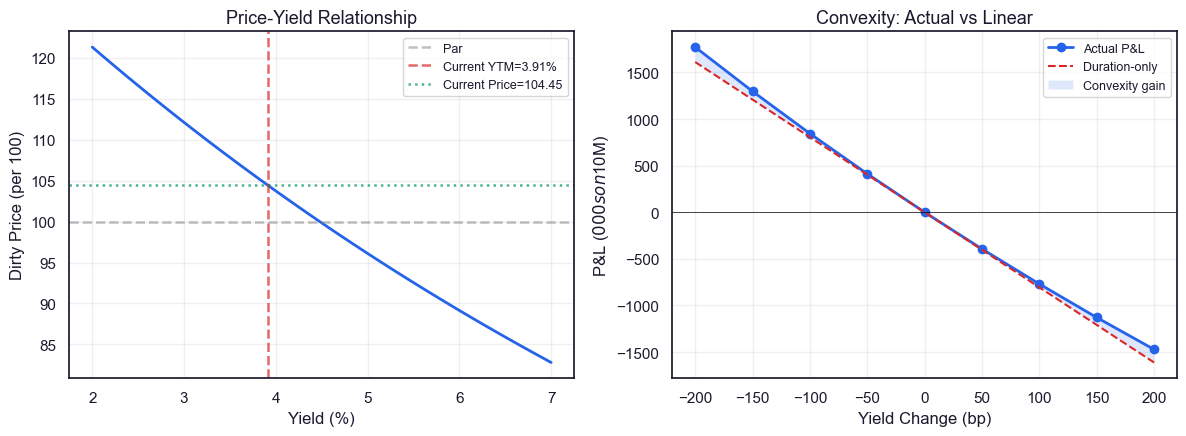

In [5]:
from pricebook.viz._backend import apply_theme, create_figure

# Price-yield curve and convexity — using pricebook viz theme
yields_range = np.linspace(0.02, 0.07, 50)
prices_range = [tnote._price_from_ytm(y, settle) for y in yields_range]

with apply_theme():
    fig, (ax1, ax2) = create_figure(2)

    ax1.plot(yields_range * 100, prices_range, linewidth=2)
    ax1.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Par')
    ax1.axvline(ytm * 100, color='#dc2626', linestyle='--', alpha=0.7, label=f'Current YTM={ytm*100:.2f}%')
    ax1.axhline(dirty, color='#059669', linestyle=':', alpha=0.7, label=f'Current Price={dirty:.2f}')
    ax1.set_xlabel("Yield (%)")
    ax1.set_ylabel("Dirty Price (per 100)")
    ax1.set_title("Price-Yield Relationship")
    ax1.legend(fontsize=9)

    # Convexity illustration
    bumps = np.array([-200, -150, -100, -50, 0, 50, 100, 150, 200])
    actual = [(tnote._price_from_ytm(ytm + b/1e4, settle) - dirty) * face / 100 for b in bumps]
    linear = [(-rm.modified_duration * dirty / 100 * b / 1e4) * face for b in bumps]

    ax2.plot(bumps, [a/1e3 for a in actual], 'o-', label='Actual P&L', linewidth=2)
    ax2.plot(bumps, [l/1e3 for l in linear], '--', label='Duration-only', linewidth=1.5)
    ax2.fill_between(bumps, [a/1e3 for a in actual], [l/1e3 for l in linear], alpha=0.15, label='Convexity gain')
    ax2.set_xlabel("Yield Change (bp)")
    ax2.set_ylabel("P&L ($000s on $10M)")
    ax2.set_title("Convexity: Actual vs Linear")
    ax2.legend(fontsize=9)
    ax2.axhline(0, color='black', linewidth=0.5)

    fig.tight_layout()

# 32nds pricing table
print(f"\n{'Yield Chg (bp)':>14}  {'Yield':>7}  {'Price':>10}  {'32nds':>10}  {'P&L ($10M)':>12}")
print(f"{'─'*14}  {'─'*7}  {'─'*10}  {'─'*10}  {'─'*12}")
for bp in [-50, -25, -10, -5, 0, 5, 10, 25, 50]:
    y = ytm + bp / 10000
    p = tnote._price_from_ytm(y, settle)
    pnl = (p - dirty) * face / 100
    marker = " ←" if bp == 0 else ""
    print(f"{bp:>+14}  {y*100:>6.2f}%  {p:>10.4f}  {to_32nds(p):>10}  ${pnl:>+11,.0f}{marker}")

## Summary

| Item | Value | Method |
|------|-------|--------|
| Pricing | Discount cashflows via SOFR curve | `bond.dirty_price(curve)` |
| Yield | Semi-annual compounding | `bond.yield_to_maturity(price, settle)` |
| Accrued | ACT/ACT ICMA | `bond.accrued_interest(settle)` |
| Duration | Macaulay, Modified, Effective | `bond_risk_metrics()` |
| DV01 | Yield-based and curve-based | Bump-and-reprice |
| Carry | Coupon - financing + roll-down | `bond_carry_roll()` |
| Quoting | 32nds with + notation | `to_32nds()` / `from_32nds()` |
| Roundtrip | Price → yield → price | Error < 1e-10 |